In [ ]:
# seeds:



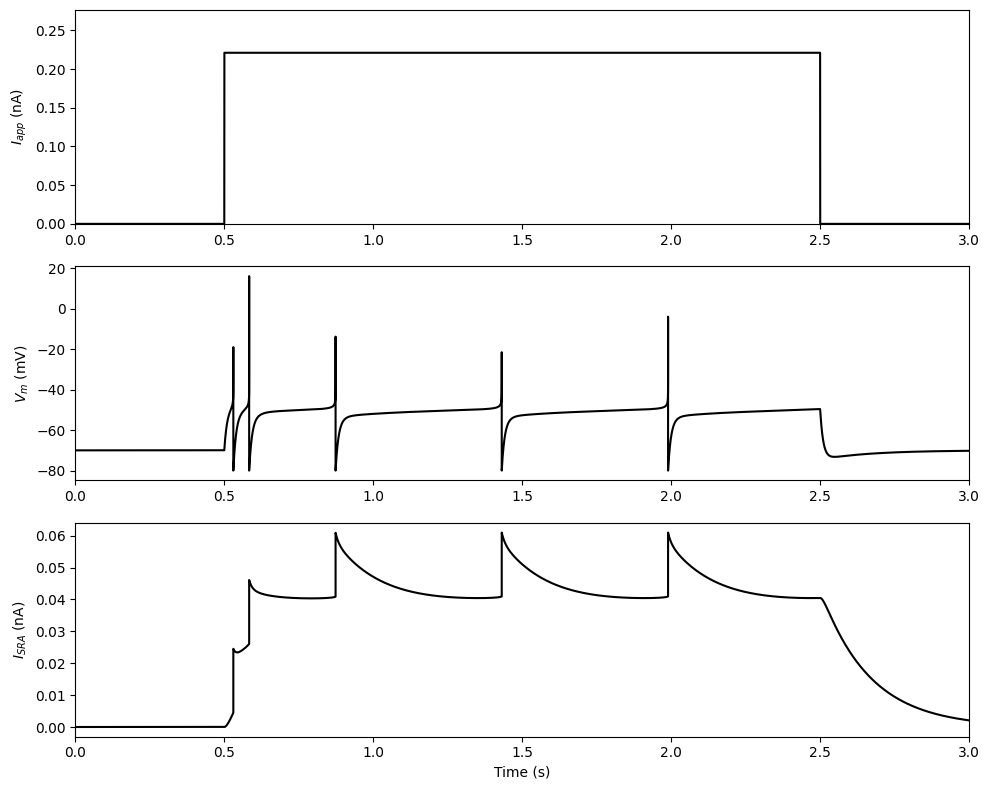

In [4]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Cell Parameters
# ============================================================

G_L_example = 10e-9          # Leak conductance (S)
C_example = 100e-12          # Capacitance (F)
E_L_example = -70e-3         # Leak potential (V)

V_thresh_example = -50e-3    # Threshold potential (V)
V_reset_example = -80e-3     # Reset potential (V)

deltaT_example = 2e-3        # Threshold slope factor (V)

tau_w_example = 200e-3       # Adaptation time constant (s)
a_example = 2e-9             # Adaptation recovery (S)
b_example = 0.02e-9          # Spike-triggered adaptation increment (A)

I0_example = 0e-9            # Baseline current
Iapp_example = 0.221e-9      # Applied current step

Vmax_example = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt_example = 1e-6            # Time step (s)
tmax_example = 3             # Total simulation time (s)

t_example = np.arange(0, tmax_example + dt_example, dt_example)

# Current step timing
ton_example = 0.5
toff_example = 2.5

non_example = int(ton_example / dt_example)
noff_example = int(toff_example / dt_example)

# ============================================================
# Input Current
# ============================================================

I_example = I0_example * np.ones_like(t_example)
I_example[non_example:noff_example] = Iapp_example

# ============================================================
# State Variables
# ============================================================

v_example = np.zeros_like(t_example)
w_example = np.zeros_like(t_example)
spikes_example = np.zeros_like(t_example)

# Initial condition
v_example[0] = E_L_example

# ============================================================
# Simulation Loop
# ============================================================

for j_example in range(len(t_example) - 1):

    # Spike detection and reset
    if v_example[j_example] > Vmax_example:
        v_example[j_example] = V_reset_example
        w_example[j_example] += b_example
        spikes_example[j_example] = 1

    # Membrane potential update
    dv_example = (
        G_L_example * (
            E_L_example
            - v_example[j_example]
            + deltaT_example * np.exp((v_example[j_example] - V_thresh_example) / deltaT_example)
        )
        - w_example[j_example]
        + I_example[j_example]
    ) / C_example

    v_example[j_example + 1] = v_example[j_example] + dt_example * dv_example

    # Adaptation update
    dw_example = (a_example * (v_example[j_example] - E_L_example) - w_example[j_example]) / tau_w_example

    w_example[j_example + 1] = w_example[j_example] + dt_example * dw_example

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t_example, 1e9 * I_example, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, tmax_example)
plt.ylim(0, 1.25 * np.max(1e9 * I_example))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t_example, 1000 * v_example, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, tmax_example)
#plt.ylim(-95, 35)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t_example, 1e9 * w_example, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, tmax_example)

plt.tight_layout()

plt.show()

## Tut 3.1

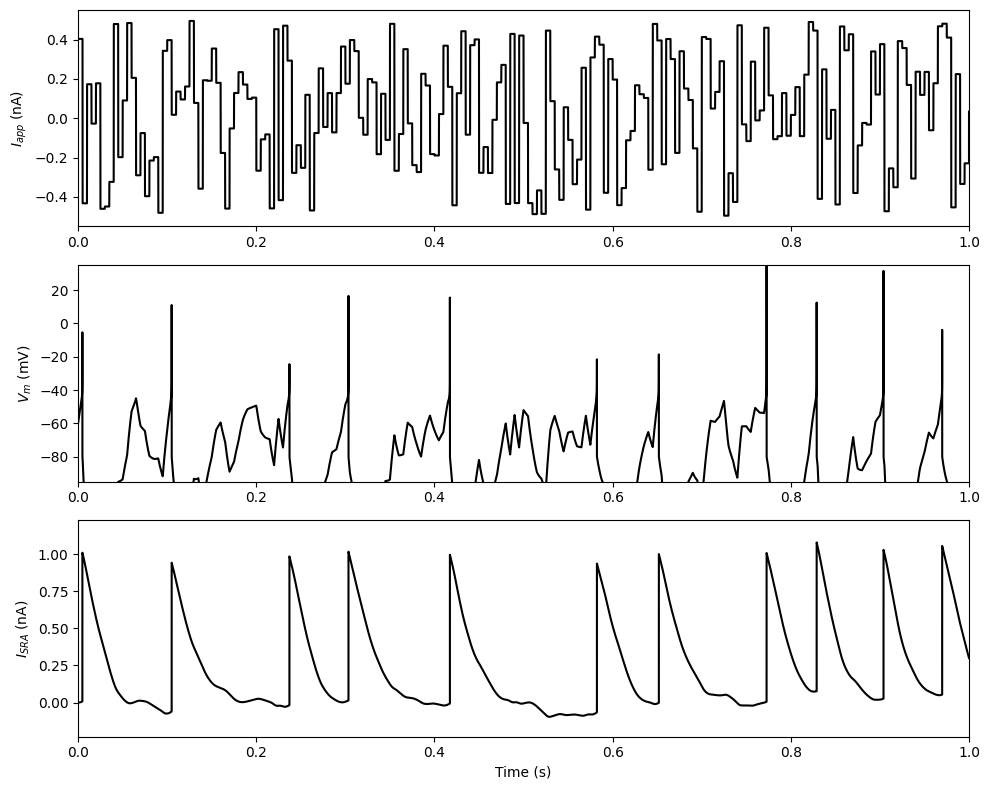

In [1]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

import numpy as np
import matplotlib.pyplot as plt

seed = 31

# ============================================================
# Cell Parameters
# ============================================================

G_L = 8e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -60e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 50e-3       # Adaptation time constant (s)
a = 10e-9             # Adaptation recovery (S)
b = 1.e-9          # Spike-triggered adaptation increment (A)

#I0 = 0e-9            # Baseline current
#Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.02e-3            # Time step (s)
tmax = 40000*5e-3             # Total simulation time (s)

data = np.load(f'data/tut_data_3_1_{seed}.npz') # Load the data from the .npz file
t = data['t']
I = data['I']

#t = np.arange(0, tmax + dt, dt)
#
## Current step timing
#ton = 0.5
#toff = 2.5
#
#non = int(ton / dt)
#noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp

# ============================================================
# State Variables
# ============================================================

v_3_1 = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_1 = np.zeros_like(t)

# Initial condition
v_3_1[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v_3_1[j] > Vmax:
        v_3_1[j] = V_reset
        w[j] += b
        spikes_3_1[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v_3_1[j]
            + deltaT * np.exp((v_3_1[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v_3_1[j + 1] = v_3_1[j] + dt * dv

    # Adaptation update
    dw = (a * (v_3_1[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_1'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v_3_1, w=w, I=I, spikes=spikes_3_1)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 1000e-3)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v_3_1, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 1000e-3)
plt.ylim(-95, 35)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, 1000e-3)

plt.tight_layout()

plt.show()

## Tut 3.2

### a.

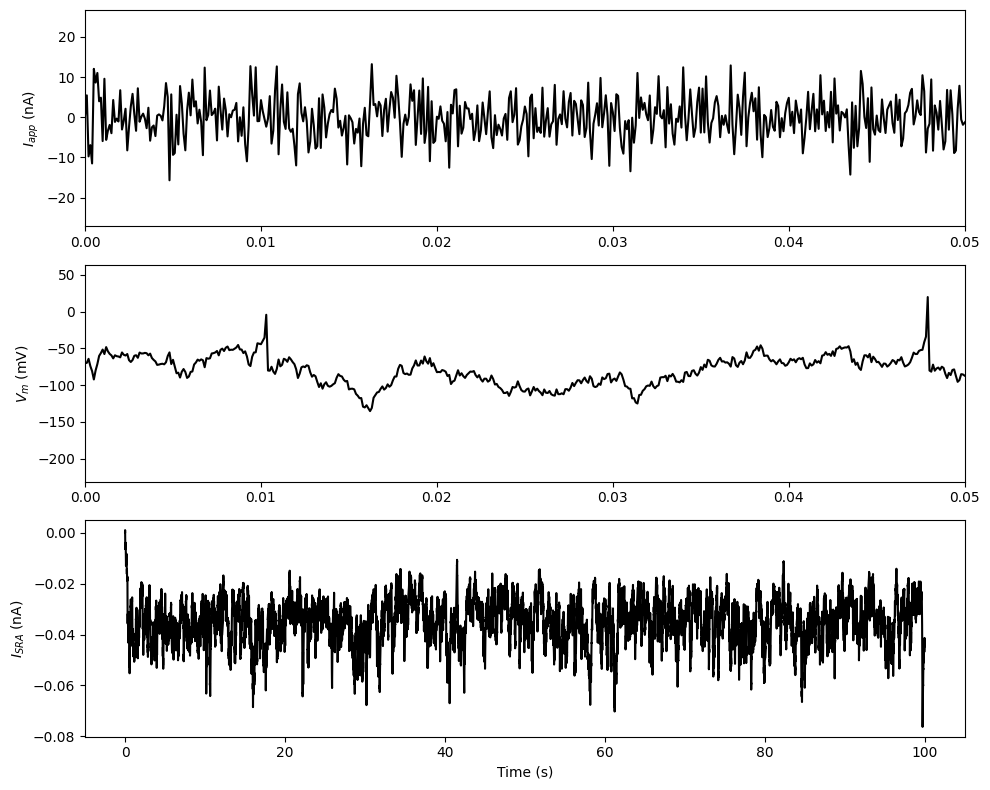

In [ ]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

seed = 321

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(8)  # for reproducibility

# ============================================================
# Cell Parameters
# ============================================================

G_L = 10e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -70e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 150e-3       # Adaptation time constant (s)
a = 2e-9             # Adaptation recovery (S)
b = 0.0e-9          # Spike-triggered adaptation increment (A)

I0 = 0e-9            # Baseline current
Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.1e-3            # Time step (s)
tmax = 100             # Total simulation time (s)

t = np.arange(0, tmax + dt, dt)

# Current step timing
ton = 0.5
toff = 2.5

non = int(ton / dt)
noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

mean = 0.0
sigma = 50e-12 #A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt) 
#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp
I = np.random.normal(mean, standard_deviation, len(t))

# ============================================================
# State Variables
# ============================================================

v = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_2 = np.zeros_like(t)

# Initial condition
v[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v[j] > Vmax:
        v[j] = V_reset
        w[j] += b
        spikes_3_2[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v[j]
            + deltaT * np.exp((v[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v[j + 1] = v[j] + dt * dv

    # Adaptation update
    dw = (a * (v[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_2'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v, w=w, I=I, spikes=spikes_3_2)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 0.05)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 0.05)
#plt.ylim(-15000, 60)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

#plt.xlim(0, 0.05)

plt.tight_layout()

plt.show()

### b.

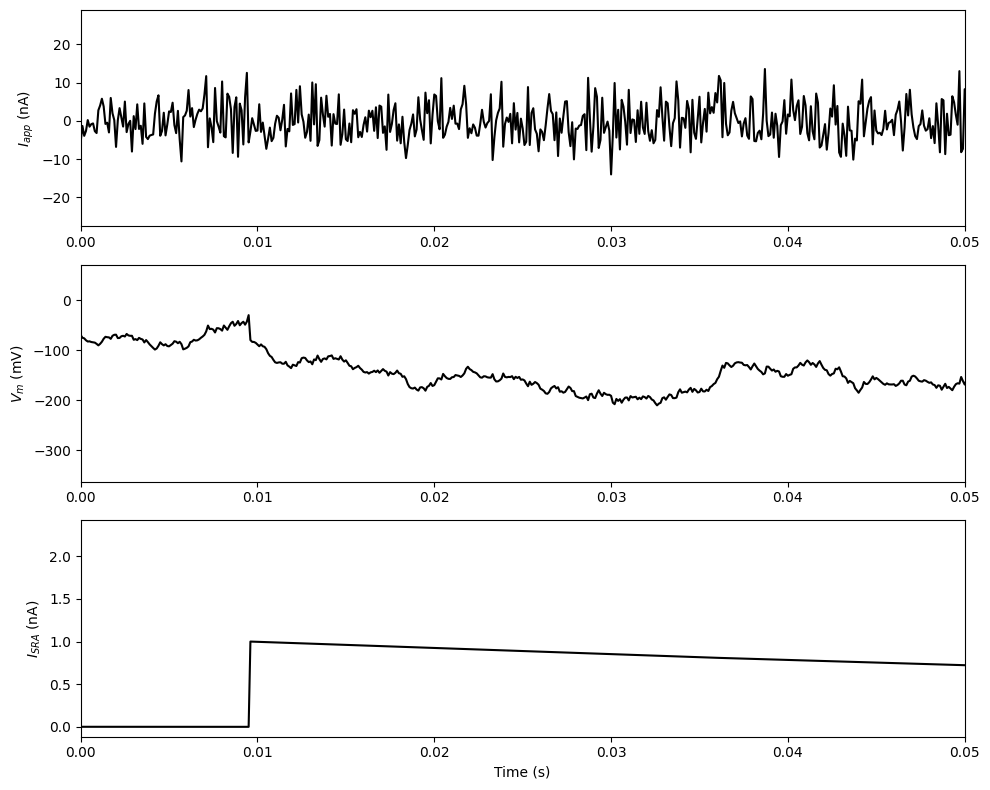

In [1]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

import numpy as np
import matplotlib.pyplot as plt

seed = 322
np.random.seed(seed)  # for reproducibility

# ============================================================
# Cell Parameters
# ============================================================

G_L = 10e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -70e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 150e-3       # Adaptation time constant (s)
a = 2e-9             # Adaptation recovery (S)
b = 1.0e-9          # Spike-triggered adaptation increment (A)

I0 = 0e-9            # Baseline current
Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.1e-3            # Time step (s)
tmax = 100             # Total simulation time (s)

t = np.arange(0, tmax + dt, dt)

# Current step timing
ton = 0.5
toff = 2.5

non = int(ton / dt)
noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

mean = 0.0
sigma = 50e-12 #A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt) 
#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp
I = np.random.normal(mean, standard_deviation, len(t))

# ============================================================
# State Variables
# ============================================================

v = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_2 = np.zeros_like(t)

# Initial condition
v[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v[j] > Vmax:
        v[j] = V_reset
        w[j] += b
        spikes_3_2[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v[j]
            + deltaT * np.exp((v[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v[j + 1] = v[j] + dt * dv

    # Adaptation update
    dw = (a * (v[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_2'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v, w=w, I=I, spikes=spikes_3_2)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 0.05)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 0.05)
#plt.ylim(-15000, 60)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, 0.05)

plt.tight_layout()

plt.show()

### c.

#### $I_0$

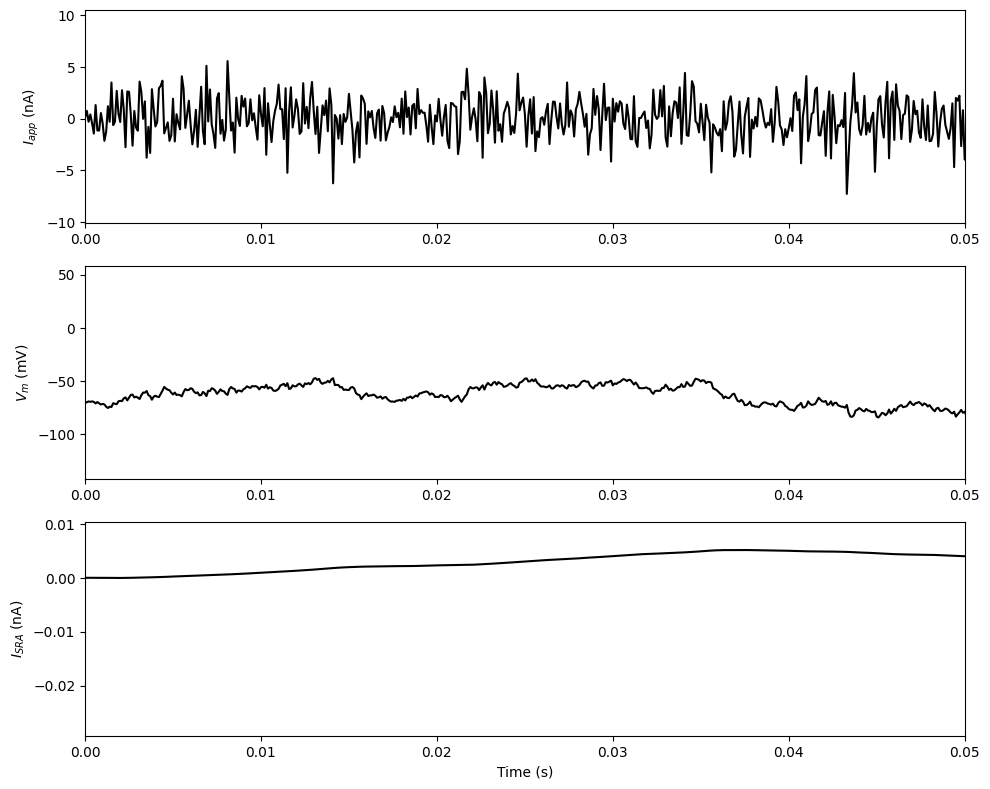

In [1]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

seed = 323

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(seed)  # for reproducibility

# ============================================================
# Cell Parameters
# ============================================================

G_L = 10e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -70e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 150e-3       # Adaptation time constant (s)
a = 2e-9             # Adaptation recovery (S)
b = 0.0e-9          # Spike-triggered adaptation increment (A)

I0 = 0e-9            # Baseline current
Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.1e-3            # Time step (s)
tmax = 100             # Total simulation time (s)

t = np.arange(0, tmax + dt, dt)

# Current step timing
ton = 0.5
toff = 2.5

non = int(ton / dt)
noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

mean = 0.0
sigma = 20e-12 #A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt) 
#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp
I = np.random.normal(mean, standard_deviation, len(t))

# ============================================================
# State Variables
# ============================================================

v = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_2 = np.zeros_like(t)

# Initial condition
v[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v[j] > Vmax:
        v[j] = V_reset
        w[j] += b
        spikes_3_2[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v[j]
            + deltaT * np.exp((v[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v[j + 1] = v[j] + dt * dv

    # Adaptation update
    dw = (a * (v[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_2'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v, w=w, I=I, spikes=spikes_3_2)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 0.05)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 0.05)
#plt.ylim(-15000, 60)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, 0.05)

plt.tight_layout()

plt.show()

#### $I_1$

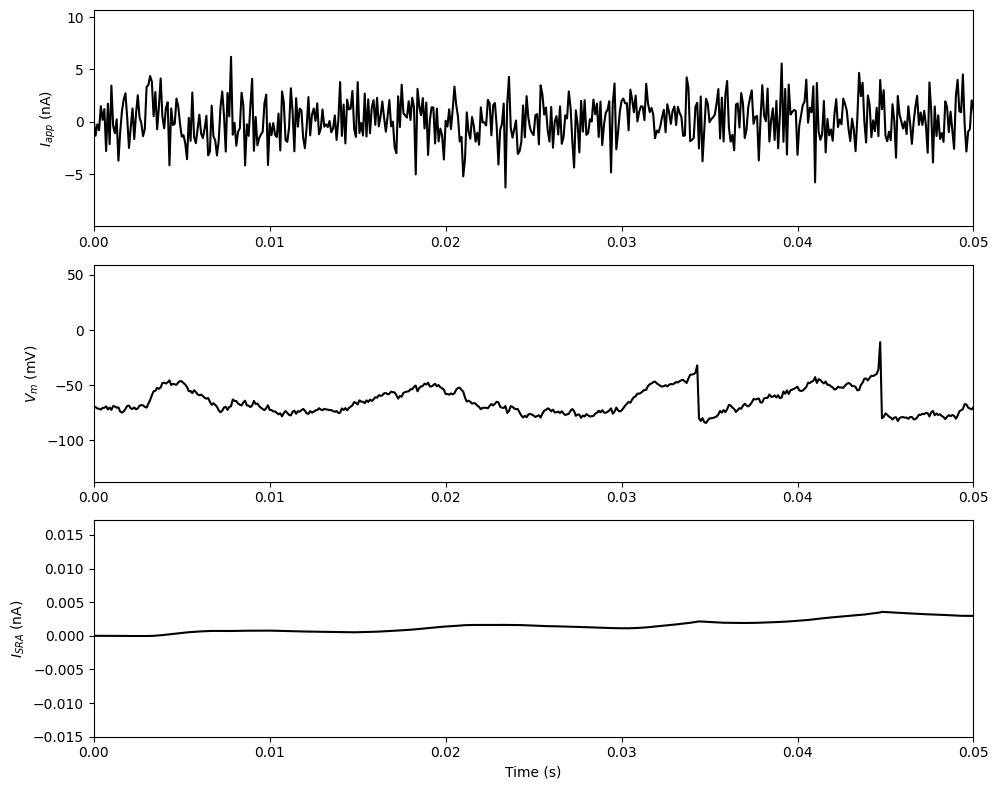

In [1]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

seed = 324

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(seed)  # for reproducibility

# ============================================================
# Cell Parameters
# ============================================================

G_L = 10e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -70e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 150e-3       # Adaptation time constant (s)
a = 2e-9             # Adaptation recovery (S)
b = 0.0e-9          # Spike-triggered adaptation increment (A)

I0 = 0e-9            # Baseline current
Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.1e-3            # Time step (s)
tmax = 100             # Total simulation time (s)

t = np.arange(0, tmax + dt, dt)

# Current step timing
ton = 0.5
toff = 2.5

non = int(ton / dt)
noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

mean = 0.0
sigma = 20e-12 #A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt) 
#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp
I = np.random.normal(mean, standard_deviation, len(t)) + 0.1e-9

# ============================================================
# State Variables
# ============================================================

v = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_2 = np.zeros_like(t)

# Initial condition
v[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v[j] > Vmax:
        v[j] = V_reset
        w[j] += b
        spikes_3_2[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v[j]
            + deltaT * np.exp((v[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v[j + 1] = v[j] + dt * dv

    # Adaptation update
    dw = (a * (v[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_2'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v, w=w, I=I, spikes=spikes_3_2)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 0.05)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 0.05)
#plt.ylim(-15000, 60)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, 0.05)

plt.tight_layout()

plt.show()

#### $I_2$

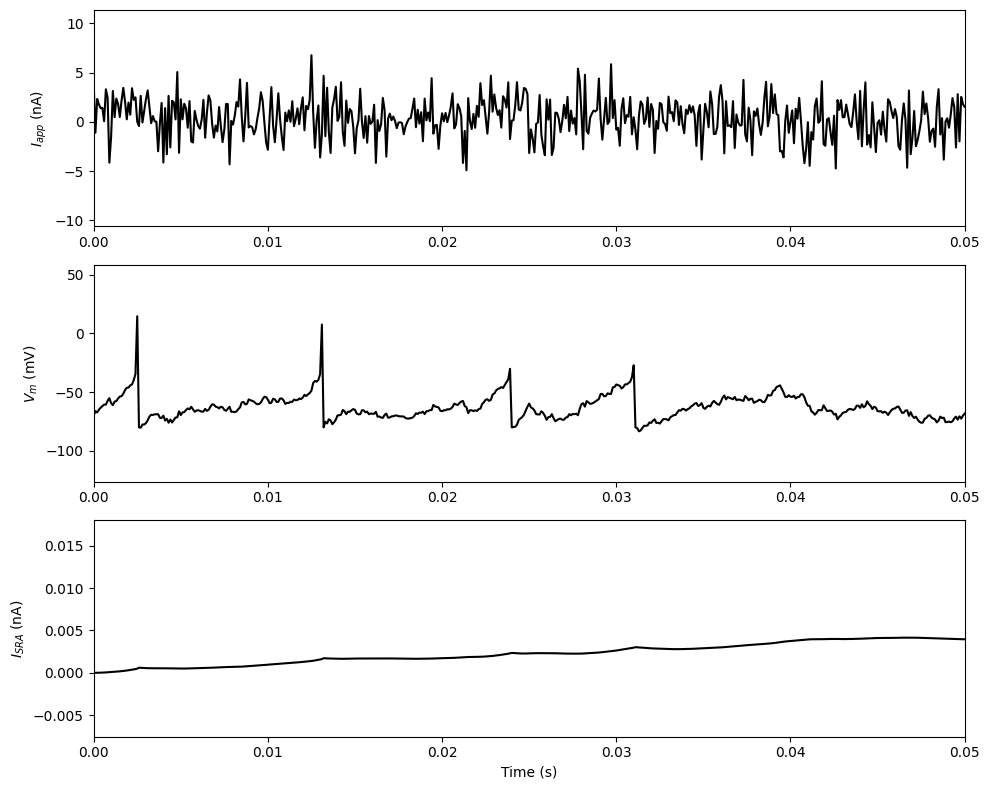

In [1]:
# AELIF_model.py
# Adaptive Exponential Leaky Integrate-and-Fire Model
# Converted from MATLAB to Python

seed = 325

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(seed)  # for reproducibility

# ============================================================
# Cell Parameters
# ============================================================

G_L = 10e-9          # Leak conductance (S)
C = 100e-12          # Capacitance (F)
E_L = -70e-3         # Leak potential (V)

V_thresh = -50e-3    # Threshold potential (V)
V_reset = -80e-3     # Reset potential (V)

deltaT = 2e-3        # Threshold slope factor (V)

tau_w = 150e-3       # Adaptation time constant (s)
a = 2e-9             # Adaptation recovery (S)
b = 0.0e-9          # Spike-triggered adaptation increment (A)

I0 = 0e-9            # Baseline current
Iapp = 0.221e-9      # Applied current step

Vmax = 50e-3         # Spike detection/cropping voltage

# ============================================================
# Simulation Parameters
# ============================================================

dt = 0.1e-3            # Time step (s)
tmax = 100             # Total simulation time (s)

t = np.arange(0, tmax + dt, dt)

# Current step timing
ton = 0.5
toff = 2.5

non = int(ton / dt)
noff = int(toff / dt)

# ============================================================
# Input Current
# ============================================================

mean = 0.0
sigma = 20e-12 #A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt) 
#I = I0 * np.ones_like(t)
#I[non:noff] = Iapp
I = np.random.normal(mean, standard_deviation, len(t)) + 0.2e-9

# ============================================================
# State Variables
# ============================================================

v = np.zeros_like(t)
w = np.zeros_like(t)
spikes_3_2 = np.zeros_like(t)

# Initial condition
v[0] = E_L

# ============================================================
# Simulation Loop
# ============================================================

for j in range(len(t) - 1):

    # Spike detection and reset
    if v[j] > Vmax:
        v[j] = V_reset
        w[j] += b
        spikes_3_2[j] = 1

    # Membrane potential update
    dv = (
        G_L * (
            E_L
            - v[j]
            + deltaT * np.exp((v[j] - V_thresh) / deltaT)
        )
        - w[j]
        + I[j]
    ) / C

    v[j + 1] = v[j] + dt * dv

    # Adaptation update
    dw = (a * (v[j] - E_L) - w[j]) / tau_w

    w[j + 1] = w[j] + dt * dw

# ============================================================
# Saving Data
# ============================================================

tut = '3_2'
info = f'{tut}_{seed}'

np.savez(f'data/aelif_data_{info}.npz', t=t, v=v, w=w, I=I, spikes=spikes_3_2)

# ============================================================
# Plotting
# ============================================================

plt.figure(figsize=(10, 8))

# ------------------------------------------------------------
# Input current
# ------------------------------------------------------------

plt.subplot(3, 1, 1)

plt.plot(t, 1e9 * I, 'k')

plt.ylabel(r'$I_{app}$ (nA)')

plt.xlim(0, 0.05)
#plt.ylim(0, 1.25 * np.max(1e9 * I))

# ------------------------------------------------------------
# Membrane voltage
# ------------------------------------------------------------

plt.subplot(3, 1, 2)

plt.plot(t, 1000 * v, 'k')

plt.ylabel(r'$V_m$ (mV)')

plt.xlim(0, 0.05)
#plt.ylim(-15000, 60)

# ------------------------------------------------------------
# Adaptation current
# ------------------------------------------------------------

plt.subplot(3, 1, 3)

plt.plot(t, 1e9 * w, 'k')

plt.xlabel('Time (s)')
plt.ylabel(r'$I_{SRA}$ (nA)')

plt.xlim(0, 0.05)

plt.tight_layout()

plt.show()